Dataset Shape: (392692, 9)

Total Revenue:
8887208.89

Unique Customers:
4338

Unique Products:
3665

Unique Transactions:
18532

Top 10 Customers:
CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64


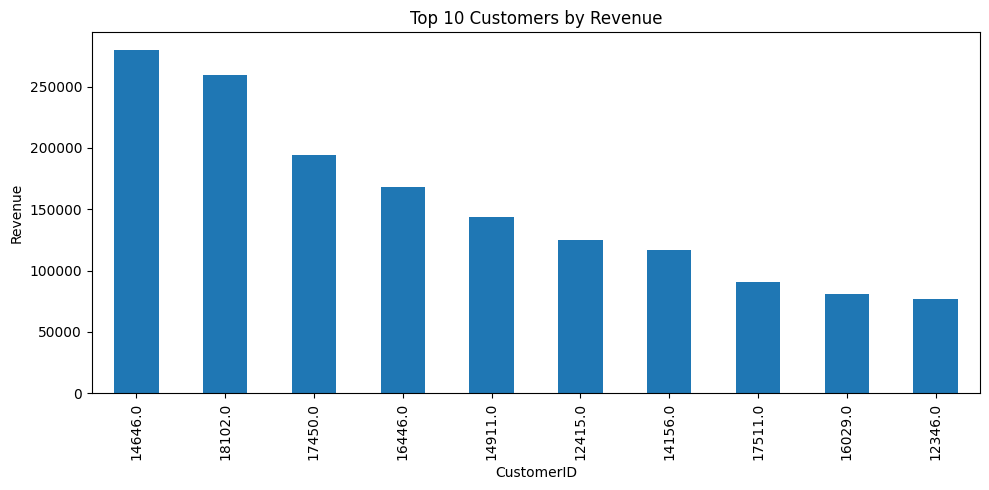

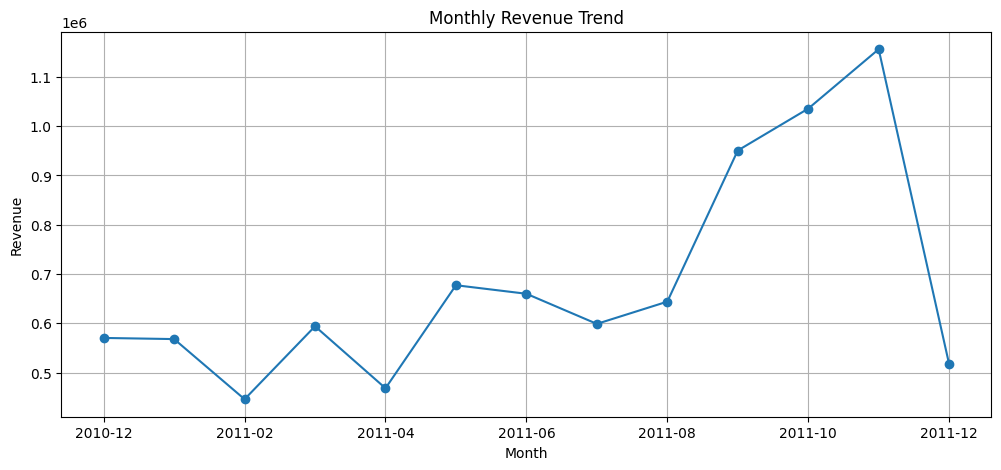


Snapshot Date:
2011-12-10 12:50:00

RFM Dataset Shape:
(4338, 4)

First 5 Customers:
   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40

RFM Statistics:
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2048.688081
std     1721.808492   100.014169     7.697998    8985.230220
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     306.482500
50%    15299.500000    51.000000     2.000000     668.570000
75%    16778.750000   142.000000     5.000000    1660.597500
max    18287.000000   374.000000   209.000000  280206.020000


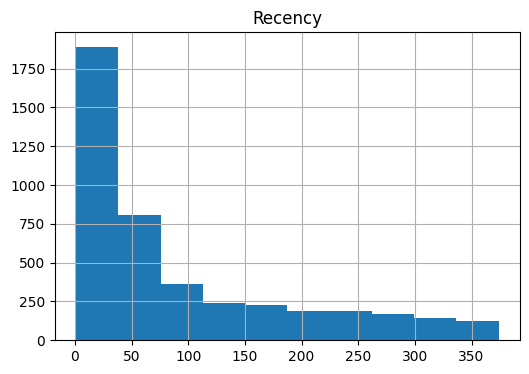

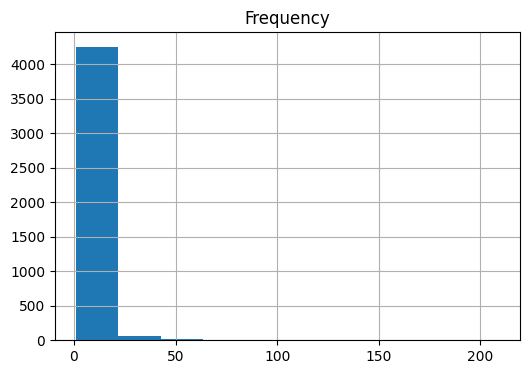

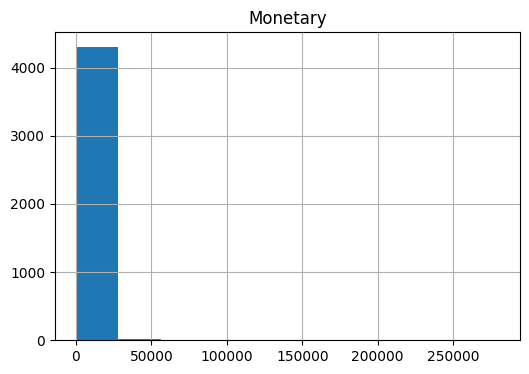


RFM Dataset Saved Successfully!


In [1]:
# ==========================================
# CUSTOMER LIFETIME VALUE PROJECT
# PHASE 3: EDA + RFM FEATURE ENGINEERING
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# Load Cleaned Dataset
# ------------------------------------------

df = pd.read_csv("../data/cleaned_online_retail.csv")

print("Dataset Shape:", df.shape)

# ------------------------------------------
# Convert InvoiceDate
# ------------------------------------------

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# ------------------------------------------
# Basic Business Insights
# ------------------------------------------

print("\nTotal Revenue:")
print(round(df["Revenue"].sum(), 2))

print("\nUnique Customers:")
print(df["CustomerID"].nunique())

print("\nUnique Products:")
print(df["StockCode"].nunique())

print("\nUnique Transactions:")
print(df["InvoiceNo"].nunique())

# ------------------------------------------
# Top 10 Customers by Revenue
# ------------------------------------------

top_customers = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("\nTop 10 Customers:")
print(top_customers)

plt.figure(figsize=(10,5))
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Revenue")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# ------------------------------------------
# Monthly Revenue Trend
# ------------------------------------------

df["YearMonth"] = (
    df["InvoiceDate"]
      .dt.to_period("M")
      .astype(str)
)

monthly_revenue = (
    df.groupby("YearMonth")["Revenue"]
      .sum()
)

plt.figure(figsize=(12,5))
monthly_revenue.plot(marker="o")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.grid(True)
plt.show()

# ------------------------------------------
# RFM FEATURE ENGINEERING
# ------------------------------------------

# Reference Date
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("\nSnapshot Date:")
print(snapshot_date)

# ------------------------------------------
# Create RFM Table
# ------------------------------------------

rfm = df.groupby("CustomerID").agg({

    "InvoiceDate": lambda x:
        (snapshot_date - x.max()).days,

    "InvoiceNo": "nunique",

    "Revenue": "sum"

})

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm = rfm.reset_index()

# ------------------------------------------
# RFM Summary
# ------------------------------------------

print("\nRFM Dataset Shape:")
print(rfm.shape)

print("\nFirst 5 Customers:")
print(rfm.head())

print("\nRFM Statistics:")
print(rfm.describe())

# ------------------------------------------
# Histograms
# ------------------------------------------

rfm[["Recency"]].hist(figsize=(6,4))
plt.show()

rfm[["Frequency"]].hist(figsize=(6,4))
plt.show()

rfm[["Monetary"]].hist(figsize=(6,4))
plt.show()

# ------------------------------------------
# Save Customer-Level Dataset
# ------------------------------------------

rfm.to_csv(
    "../data/customer_rfm.csv",
    index=False
)

print("\nRFM Dataset Saved Successfully!")